In [181]:
## checking the dataset properties

import pandas as pd

df= pd.read_csv("../Dataset/sample_tickets_dataset.csv")
print(df.shape)
print(df.columns.tolist)
print(df.dtypes)

(4500, 17)
<bound method IndexOpsMixin.tolist of Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')>
Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
Firs

In [182]:
for columns in df.columns:
    print(df[columns].value_counts())

Ticket ID
1       1
2       1
3       1
4       1
5       1
       ..
4496    1
4497    1
4498    1
4499    1
4500    1
Name: count, Length: 4500, dtype: int64
Customer Name
Felix Al-Rashid    6
Yara Ivanova       6
Aisha Nwosu        6
Chiara Mensah      6
Carlos Anderson    6
                  ..
Thomas Walker      1
Kavya White        1
Omar Wei           1
Jessica Carter     1
Aaron Diallo       1
Name: count, Length: 2356, dtype: int64
Customer Email
ethanjohnson@gmail.com         3
robertgarcia@protonmail.com    2
yuki_allen@yahoo.com           2
patrickcarter@outlook.com      2
davidsharma@protonmail.com     2
                              ..
jessica.carter@outlook.com     1
davidjohnson@protonmail.com    1
mariagoldstein@icloud.com      1
brian.hassan@hotmail.com       1
aaron.diallo639@outlook.com    1
Name: count, Length: 4467, dtype: int64
Customer Age
61    102
26     98
27     96
50     95
66     94
65     93
40     93
38     92
53     92
70     92
64     91
48     91
54  

## what we have learnt from the initial raw dataset

1. ticket type will be the main classification target, based on what type of theticket is talking about, we will predict the priority of the ticket

2. the ticket description has one main issue of having {product purchased} and {error_message} which are unfilled parameters which makes this column very weak by itelse. So we combine it with ticket subject to me used more reliablely

3. we can remove unneccessary columns like ticket id, customer name, customer emal, age, gender etc

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Sara Mensah,saramensah@outlook.com,33,Male,Massage Gun Pro,2023-03-30,Technical Issue,Something went wrong after the latest update,I've had my Massage Gun Pro for a while now bu...,Resolved,Replacement unit dispatched after fault confir...,Medium,Social Media,1d 2h,2h 45m,3.0
1,2,Derek Khan,derek.khan@me.com,38,Male,LaptopX 15,2023-10-03,Product Inquiry,I have a few questions about a product,Before I place an order for the LaptopX 15 I'd...,In Progress,Pending,Medium,Social Media,8h,Pending,NaN
2,3,Felix Brown,felixbrown@gmail.com,25,Male,SoundWave Earbuds,2024-04-30,Technical Issue,Something went wrong after the latest update,I purchased the SoundWave Earbuds 4 weeks ago ...,Open,Pending,High,Social Media,4h,Pending,NaN
3,4,Andre Wilson,andre.wilson@live.com,25,Female,KitchenBlast Blender,2023-05-28,Product Inquiry,Product question from a potential customer,i'm very close to ordering teh KitchenBlast Bl...,Resolved,Customer directed to detailed setup guide.,Medium,Chat,12h,4d 6h,4.0
4,5,Ethan Goldstein,ethan.goldstein@protonmail.com,64,Male,Massage Gun Pro,2024-03-30,Refund Request,Help with processing a refund,I'll keep this brief — two problems. I've noti...,Resolved,Partial refund approved per return policy.,Low,Chat,2h 30m,4d 6h,5.0


In [185]:
print(df.shape)

(4500, 17)


In [186]:
## checking null values
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                         0
Ticket Priority                    0
Ticket Channel                     0
First Response Time                0
Time to Resolution                 0
Customer Satisfaction Rating    2219
dtype: int64

In [187]:
## dropping unneccessary columns
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [188]:
df = df.drop(columns=['Ticket ID','Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender',
               'Date of Purchase','First Response Time','Time to Resolution','Resolution', 
               "Customer Satisfaction Rating"],errors='ignore')

In [189]:
df.head()

,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel
0,Massage Gun Pro,Technical Issue,Something went wrong after the latest update,I've had my Massage Gun Pro for a while now bu...,Resolved,Medium,Social Media
1,LaptopX 15,Product Inquiry,I have a few questions about a product,Before I place an order for the LaptopX 15 I'd...,In Progress,Medium,Social Media
2,SoundWave Earbuds,Technical Issue,Something went wrong after the latest update,I purchased the SoundWave Earbuds 4 weeks ago ...,Open,High,Social Media
3,KitchenBlast Blender,Product Inquiry,Product question from a potential customer,i'm very close to ordering teh KitchenBlast Bl...,Resolved,Medium,Chat
4,Massage Gun Pro,Refund Request,Help with processing a refund,I'll keep this brief — two problems. I've noti...,Resolved,Low,Chat


In [190]:
## checking null values again
df.isnull().sum()

Product Purchased     0
Ticket Type           0
Ticket Subject        0
Ticket Description    0
Ticket Status         0
Ticket Priority       0
Ticket Channel        0
dtype: int64

for ticket types count: 

Ticket Type
Technical Issue    1072
Product Inquiry     887
Account Access      874
Refund Request      867
Billing Inquiry     800
Name: count, dtype: int64

for ticket priority count: 

Ticket Priority
Medium      1646
Low         1239
High        1013
Critical     602
Name: count, dtype: int64


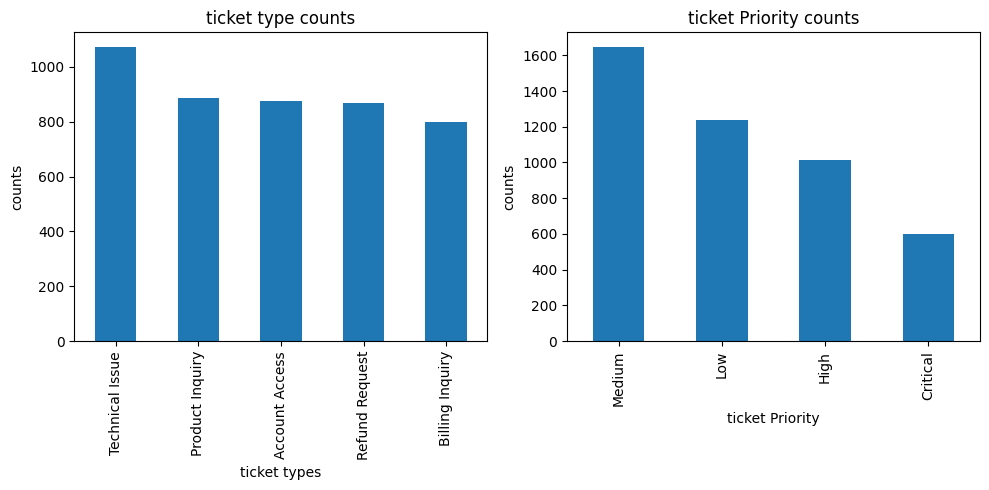

In [191]:
print("for ticket types count: \n")
print(df['Ticket Type'].value_counts())

print("\nfor ticket priority count: \n")
print(df['Ticket Priority'].value_counts())
ticket_type_counts = df['Ticket Type'].value_counts()
ticket_priority_counts = df['Ticket Priority'].value_counts()

figure, axes = plt.subplots(1,2, figsize=(10,5))

ticket_type_counts.plot(kind='bar',ax=axes[0])
axes[0].set_xlabel("ticket types")
axes[0].set_title("ticket type counts")
axes[0].set_ylabel("counts")

ticket_priority_counts.plot(kind='bar',ax=axes[1])
axes[1].set_xlabel("ticket Priority")
axes[1].set_title("ticket Priority counts")
axes[1].set_ylabel("counts")



plt.tight_layout()
plt.show()

### insight from the graphs
- technical issue has the highest ticket count while product enquirey has the least
- medium ticket priotiry is the most common where as critical ticket priority is the least

In [192]:
## checking the correlation between priority and type using heatmap
print(pd.crosstab(df['Ticket Type'], df['Ticket Priority']))
# this crosstab shows that for each type of ticket how many tickets are criticla, high, low and medium

Ticket Priority  Critical  High  Low  Medium
Ticket Type                                 
Account Access        186   190  192     306
Billing Inquiry        62   213  199     326
Product Inquiry        86   169  298     334
Refund Request         82   210  236     339
Technical Issue       186   231  314     341


<Axes: xlabel='Ticket Priority', ylabel='Ticket Type'>

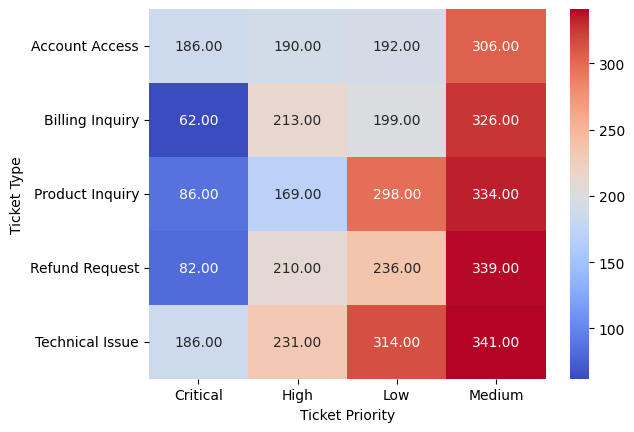

In [193]:
sns.heatmap(pd.crosstab(df['Ticket Type'], df['Ticket Priority']), annot=True,fmt=".2f", cmap="coolwarm")

### insight from heatmap
- refund requests are predominantly High priority/. 
- Product Inquiry leans Medium/Low

The signal is weak. No ticket type has one dominant priority that's clearly separated from the rest.

Ticket Channel
Social Media    1156
Phone           1124
Chat            1114
Email           1106
Name: count, dtype: int64


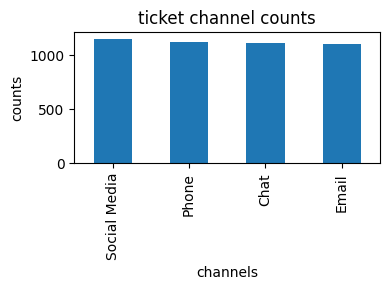

In [194]:
## observing ticket channel distribution
# here we will check choch channel gets most tickets

print(df["Ticket Channel"].value_counts())
ticket_channel_counts = df["Ticket Channel"].value_counts()

plt.figure(figsize=(4,3))

ticket_channel_counts.plot(kind="bar")
plt.title("ticket channel counts")
plt.xlabel("channels")
plt.ylabel("counts")
plt.tight_layout()

plt.show()

### insight from the channel counts
- social media and phone are the major source of connecting
- chat or email is the least used

In [195]:
## obsering text length distribution
df['description_length'] = df['Ticket Description'].str.len()
df.head()

,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Ticket Priority,Ticket Channel,description_length
0,Massage Gun Pro,Technical Issue,Something went wrong after the latest update,I've had my Massage Gun Pro for a while now bu...,Resolved,Medium,Social Media,188
1,LaptopX 15,Product Inquiry,I have a few questions about a product,Before I place an order for the LaptopX 15 I'd...,In Progress,Medium,Social Media,213
2,SoundWave Earbuds,Technical Issue,Something went wrong after the latest update,I purchased the SoundWave Earbuds 4 weeks ago ...,Open,High,Social Media,312
3,KitchenBlast Blender,Product Inquiry,Product question from a potential customer,i'm very close to ordering teh KitchenBlast Bl...,Resolved,Medium,Chat,218
4,Massage Gun Pro,Refund Request,Help with processing a refund,I'll keep this brief — two problems. I've noti...,Resolved,Low,Chat,209


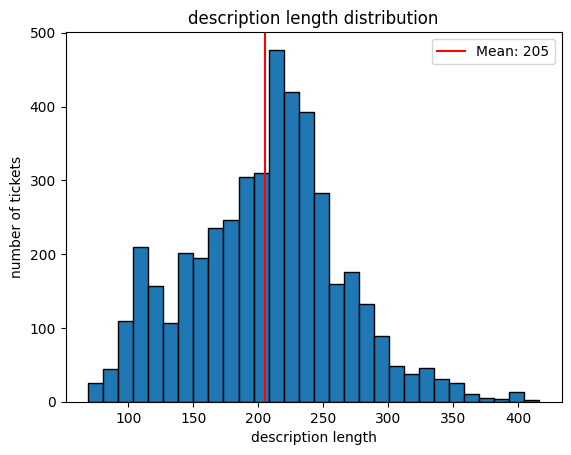

In [196]:
# plotting the histogram
plt.hist(df['description_length'], bins=30, edgecolor='black')
plt.xlabel('description length')
plt.ylabel('number of tickets')
plt.title("description length distribution")
plt.axvline(df['description_length'].mean(), color='red', label=f"Mean: {df['description_length'].mean():.0f}")
##axvline = draws a vertical line at mean
plt.legend()
plt.show()

### insights from description length distribution
- most of the tickets have characters from about 210 to 250 with the maximumn tickets being at 195 characters length
- there might be some description that might be too brief for the model to classify well